# Notebook to get the height of aurora using fieldline method (see Whiter et al. (2010))

## Map (lat, lon, alt) to image pixels using the StarCal files

LYR 78.147778N 16.039722E 523 m, NYA 78.923611N 11.930278E 10 m


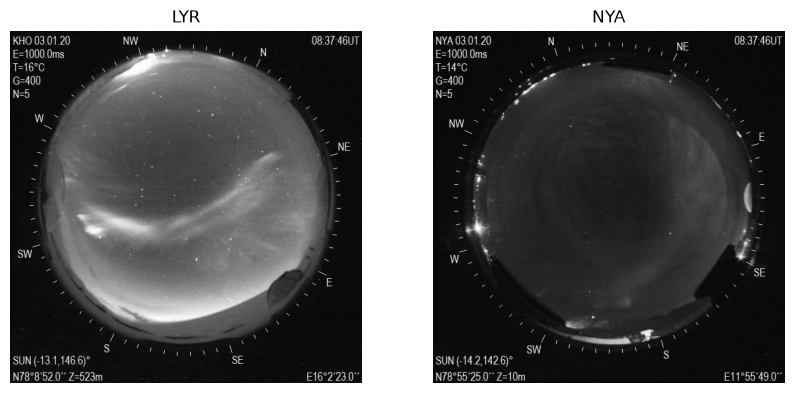

In [1]:
import os
from pathlib import Path
from datetime import datetime, timezone

import h5py
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.interpolate import LinearNDInterpolator

event_dt = datetime(2020, 1, 3, 8, 37, 46, tzinfo=timezone.utc)  # Time and date of the BACC event
# event_dt = datetime(2020, 1, 3, 8, 57, 41, tzinfo=timezone.utc)  # Time and date of the BACC event
# event_dt = datetime(2020, 1, 3, 8, 57, 50, tzinfo=timezone.utc)  # Time and date of the BACC event
# event_dt = datetime(2020, 1, 3, 8, 57, 35, tzinfo=timezone.utc)  # Time and date of the SONY event
# event_dt = datetime(2021, 12, 15, 9, 2, 2, tzinfo=timezone.utc)  # Time and date of 2021-12-15 Sony event
date_time = event_dt.strftime("%Y%m%d%H%M%S")
unixtime = int(event_dt.timestamp())

R_EARTH_KM = 6371.2  # Earth radius [km]; also used by field-line tracing

DATA = Path("Data")
save_dir = f"out/greyscale_out_fiedline_WISC_{date_time}"
os.makedirs(save_dir, exist_ok=True)


def azel_to_uv(az_deg, el_deg):
    """Map azimuth/elevation to a wrap-safe zenith-angle plane."""
    z = 90.0 - np.asarray(el_deg, dtype=float)
    a = np.radians(np.asarray(az_deg, dtype=float))
    return z * np.sin(a), z * np.cos(a)


class Station:
    """All-sky camera with WISC StarCal az/el grids in raw pixel coordinates."""

    def __init__(self, name, image_path, cal_path, el_min=15.0, subsample=4):
        self.name = name
        with h5py.File(cal_path, "r") as handle:
            attrs = dict(handle.attrs)
            az_corner = handle["azimuth_deg"][:].astype(np.float64)
            el_corner = handle["elevation_deg"][:].astype(np.float64)
        self.lat = float(np.ravel(attrs["site_lat_deg"])[0])
        self.lon = float(np.ravel(attrs["site_lon_deg"])[0])
        self.alt_km = float(np.ravel(attrs["site_alt_m"])[0]) / 1000.0
        self.width = int(np.ravel(attrs["image_width"])[0])
        self.height = int(np.ravel(attrs["image_height"])[0])
        for key in ("flip_image_x", "flip_image_y"):
            if int(np.ravel(attrs.get(key, [0]))[0]) != 0:
                raise NotImplementedError(f"{Path(cal_path).name} sets {key}=1")

        image = np.asarray(Image.open(image_path), dtype=np.float64)
        if image.ndim == 3:
            image = image.mean(axis=2)
        if image.shape != (self.height, self.width):
            raise ValueError(
                f"{Path(image_path).name} is {image.shape[1]}x{image.shape[0]} "
                f"but calibration describes {self.width}x{self.height}"
            )
        self.image = image

        expected = (self.height + 1, self.width + 1)
        if az_corner.shape != expected:
            raise ValueError(
                f"{Path(cal_path).name}: azimuth grid {az_corner.shape}, expected {expected}"
            )

        u_c, v_c = azel_to_uv(az_corner, el_corner)
        self.u = 0.25 * (u_c[:-1, :-1] + u_c[:-1, 1:] + u_c[1:, :-1] + u_c[1:, 1:])
        self.v = 0.25 * (v_c[:-1, :-1] + v_c[:-1, 1:] + v_c[1:, :-1] + v_c[1:, 1:])
        self.el = 0.25 * (
            el_corner[:-1, :-1]
            + el_corner[:-1, 1:]
            + el_corner[1:, :-1]
            + el_corner[1:, 1:]
        )
        self.el_min = el_min
        self._build_inverse(subsample)

    def _build_inverse(self, step):
        py, px = np.mgrid[0 : self.height : step, 0 : self.width : step]
        u, v, el = self.u[::step, ::step], self.v[::step, ::step], self.el[::step, ::step]
        inside = el > self.el_min
        if inside.sum() < 100:
            raise ValueError(f"{self.name}: almost nothing above el_min")
        self._interp = LinearNDInterpolator(
            np.column_stack([u[inside], v[inside]]),
            np.column_stack([px[inside].astype(float), py[inside].astype(float)]),
        )

    def azel_to_pixel(self, az_deg, el_deg):
        az = np.atleast_1d(np.asarray(az_deg, dtype=float))
        el = np.atleast_1d(np.asarray(el_deg, dtype=float))
        u, v = azel_to_uv(az, el)
        out = np.full((az.size, 2), np.nan)
        ok = np.isfinite(u) & np.isfinite(v) & (el > self.el_min)
        if ok.any():
            out[ok] = self._interp(np.column_stack([u[ok], v[ok]]))
        px, py = out[:, 0], out[:, 1]
        off = ~(
            np.isfinite(px)
            & np.isfinite(py)
            & (px >= 0)
            & (px <= self.width - 1)
            & (py >= 0)
            & (py <= self.height - 1)
        )
        px[off] = np.nan
        py[off] = np.nan
        return px, py


lyr = Station("LYR", DATA / "greyscale_BACC_LYR_20200103_083746.png", DATA / "StarCal_BACC_LYR_2020.h5")
nya = Station("NYA", DATA / "greyscale_BACC_NYA_20200103_083746.png", DATA / "StarCal_BACC_NYA_2020.h5") #BACC
# lyr = Station("LYR", DATA / "BACC_LYR2020.png", DATA / "StarCal_BACC_LYR_2020.h5")
# nya = Station("NYA", DATA / "BACC_NYA2020.png", DATA / "StarCal_BACC_NYA_2020.h5") #BACC
# lyr = Station("LYR", DATA / "RGB_product_BACC_LYR_20200103_085750.png", DATA / "StarCal_BACC_LYR_2020.h5")
# nya = Station("NYA", DATA / "RGB_product_BACC_NYA_20200103_085750.png", DATA / "StarCal_BACC_NYA_2020.h5") #BACC
# lyr = Station("LYR", DATA / "greyscale_BACC_LYR_20200103_085741.png", DATA / "StarCal_BACC_LYR_2020.h5")
# nya = Station("NYA", DATA / "greyscale_BACC_NYA_20200103_085741.png", DATA / "StarCal_BACC_NYA_2020.h5") #BACC
# lyr = Station("LYR", DATA / "LYR2020.jpg", DATA / "StarCal_LYR_2020.h5")
# nya = Station("NYA", DATA / "NYA2020.JPG", DATA / "StarCal_NYA_2020.h5")
# lyr = Station("LYR", DATA / "RGB_product_LYR-Sony-151221_090202.jpg", DATA / "StarCal_LYR_2021.h5") # 2021-12-15 Sony
# nya = Station("NYA", DATA / "C004_20211215_090201.png", DATA / "StarCal_NYA_2021.h5")
print(
    f"LYR {lyr.lat:.6f}N {lyr.lon:.6f}E {lyr.alt_km*1000:.0f} m, "
    f"NYA {nya.lat:.6f}N {nya.lon:.6f}E {nya.alt_km*1000:.0f} m"
)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(lyr.image, cmap="gray")
ax[0].set_title("LYR")
ax[0].axis("off")
ax[1].imshow(nya.image, cmap="gray")
ax[1].set_title("NYA")
ax[1].axis("off")
plt.show()

## Function settings for the magnetic field line tracing method

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import PyGeopack as gp
from scipy.ndimage import map_coordinates
from scipy.signal import medfilt

# Create date in YYYYYMMDD format
dates = int(event_dt.strftime("%Y%m%d"))
# Calculate UT (time) (decimal format: hours + minutes/60 + seconds/3600)
ut_time = event_dt.hour + event_dt.minute / 60 + event_dt.second / 3600


def geo_to_ecef(lat_deg, lon_deg, alt_km):
    lat = np.radians(np.asarray(lat_deg, dtype=float))
    lon = np.radians(np.asarray(lon_deg, dtype=float))
    r = R_EARTH_KM + np.asarray(alt_km, dtype=float)
    return np.stack(
        [r * np.cos(lat) * np.cos(lon), r * np.cos(lat) * np.sin(lon), r * np.sin(lat)],
        axis=-1,
    )


def azel_from_station(station, lat, lon, alt_km):
    origin = geo_to_ecef(station.lat, station.lon, station.alt_km)
    target = geo_to_ecef(lat, lon, alt_km)
    d = target - origin
    slat, slon = np.radians(station.lat), np.radians(station.lon)
    east = np.array([-np.sin(slon), np.cos(slon), 0.0])
    north = np.array(
        [-np.sin(slat) * np.cos(slon), -np.sin(slat) * np.sin(slon), np.cos(slat)]
    )
    up = np.array(
        [np.cos(slat) * np.cos(slon), np.cos(slat) * np.sin(slon), np.sin(slat)]
    )
    e, n, u = d @ east, d @ north, d @ up
    rng = np.sqrt(e**2 + n**2 + u**2)
    with np.errstate(invalid="ignore", divide="ignore"):
        elev = np.degrees(np.arcsin(np.where(rng > 0, u / rng, np.nan)))
    azim = np.degrees(np.arctan2(e, n)) % 360.0
    return azim, elev


def field_line_tracing(lat_fl, lon_fl, alt_fl, upper, lower, interval):
    """
    A version that uses `alt_fl` as the central altitude,
    where the actual starting point of the trace is at `(alt_fl + upper)`,
    and follows the magnetic field lines only downwards from that point.
    """

    lat_fieldline = []
    lon_fieldline = []
    alt_fieldline = []

    # Altitude range to be tracked (top to bottom)
    alt_top    = alt_fl + upper
    alt_bottom = alt_fl - lower
    alt_range  = np.arange(alt_top, alt_bottom - 1e-6, -interval)

    # The starting point is alt_top ( = alt_fl + upper)
    r_geo = (R_EARTH_KM + alt_top) / R_EARTH_KM   # given in Re (Earth radii)

    lat_rad = np.deg2rad(lat_fl)
    lon_rad = np.deg2rad(lon_fl)

    # (x, y, z) in GEO at alt_top
    x_geo = r_geo * np.cos(lat_rad) * np.cos(lon_rad)
    y_geo = r_geo * np.cos(lat_rad) * np.sin(lon_rad)
    z_geo = r_geo * np.sin(lat_rad)

    # ECEF/GEO (Earth-centered, Earth-fixed/geocentric) → Geocentric Solar Magnetospheric (GSM) 
    # The starting point remains the same throughout!
    x_gsm, y_gsm, z_gsm = gp.Coords.GEOtoGSM(x_geo, y_geo, z_geo, dates, ut_time)

    # From alt_top to alt_bottom, trace only downwards
    for alt in alt_range:
        trace = gp.TraceField(x_gsm, y_gsm, z_gsm,
                              dates, ut_time,
                              coord_In='GSM', alt=alt)

        lat_fieldline.append(trace.GlatN)
        lon_fieldline.append(trace.GlonN)
        alt_fieldline.append(alt)

    # If we reorder the altitudes here in ascending order (from ‘low’ to ‘high’),
    # the orientation will match that of the existing profile rendering
    lat_fieldline  = lat_fieldline[::-1]
    lon_fieldline  = lon_fieldline[::-1]
    alt_fieldline  = alt_fieldline[::-1]

    return lat_fieldline, lon_fieldline, alt_fieldline

def inverse_mapping(lat_fieldline, lon_fieldline, alt_fieldline, station):
    """Pixel coordinates in the raw StarCal image from latitude, longitude, and altitude."""
    lat = np.array([np.ravel(v)[0] for v in lat_fieldline], dtype=float)
    lon = np.array([np.ravel(v)[0] for v in lon_fieldline], dtype=float)
    alt = np.array([np.ravel(v)[0] for v in alt_fieldline], dtype=float)
    az, el = azel_from_station(station, lat, lon, alt)
    px, py = station.azel_to_pixel(az, el)
    return px, py

The $GEOPACK_PATH variable has not been set, this module will not function correctly without it
Data file does not exist - to create data file run "PyGeopack.Params.UpdateParameters()"
Loading Model Parameter File:



In [3]:
def brightness_vs_altitude(px_lyr, py_lyr, px_nya, py_nya, alt_fieldline):
    def sample(image, x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        good = np.isfinite(x) & np.isfinite(y)
        out = np.full(x.shape, np.nan)
        if good.any():
            out[good] = map_coordinates(
                image, [y[good], x[good]], order=1, mode="nearest"
            )
        return out

    brightness_LYR = sample(lyr.image, px_lyr, py_lyr)
    brightness_NYA = sample(nya.image, px_nya, py_nya)
    return brightness_LYR, brightness_NYA, np.asarray(alt_fieldline)

In [4]:
def fit_and_find_peak_med(altitudes, brightness):
    valid_idx = ~np.isnan(brightness)
    altitudes, brightness = altitudes[valid_idx], brightness[valid_idx]

    if len(altitudes) == 0:
        return None, None, None

    brightness_smooth = medfilt(brightness, kernel_size=3)

    peak_idx = np.argmax(brightness_smooth)
    peak_altitude = altitudes[peak_idx]
    peak_brightness = brightness_smooth[peak_idx]

    return altitudes, brightness_smooth, (peak_altitude, peak_brightness)

def fit_and_find_peak(altitudes, brightness):
    valid_idx = ~np.isnan(brightness)  # Remove NaN values
    altitudes, brightness = altitudes[valid_idx], brightness[valid_idx]

    if len(altitudes) < 4:  # Not enough data for cubic fitting
        return None, None, None

    poly_coeffs = np.polyfit(altitudes, brightness, 3)  # Cubic fit
    poly_func = np.poly1d(poly_coeffs)  # Create polynomial function

    # Generate smooth curve for plotting
    alt_smooth = np.linspace(min(altitudes), max(altitudes), 100)
    brightness_smooth = poly_func(alt_smooth)

    # Find peak (maximum value of the fitted curve)
    peak_idx = np.argmax(brightness_smooth)
    peak_altitude = alt_smooth[peak_idx]
    peak_brightness = brightness_smooth[peak_idx]

    return poly_func, peak_altitude, peak_brightness

def calculation_for_conditions(brightness_LYR, brightness_NYA, alt_fieldline):
    """
    Parameters:
        brightness_LYR (list): list of brightness values for LYR.
        brightness_NYA (list): list of brightness values for NYA.
        alt_fieldline (list): list of altitudes for each point.

    Returns:
        dict: Dictionary containing correlation, peak altitude, peak brightness, centre, percentile ratio,
              mean brightness above peak altitude, mean brightness below peak altitude for both graphs.
    """
    # Remove NaN values for correlation computation
    valid_indices = ~np.isnan(brightness_LYR) & ~np.isnan(brightness_NYA)
    correlation = np.corrcoef(brightness_LYR[valid_indices], brightness_NYA[valid_indices])[0, 1]

    poly_func_LYR, peak_alt_LYR, peak_brightness_LYR = fit_and_find_peak(alt_fieldline, brightness_LYR)
    poly_func_NYA, peak_alt_NYA, peak_brightness_NYA = fit_and_find_peak(alt_fieldline, brightness_NYA)

    # Compute Centre (Σ(brightness_values * altitude) / Σbrightness_values)
    def compute_centre(altitudes, brightness_values):
        valid_idx = ~np.isnan(brightness_values)
        altitudes, brightness_values = altitudes[valid_idx], brightness_values[valid_idx]
        return np.sum(brightness_values * altitudes) / np.sum(brightness_values) if np.sum(brightness_values) != 0 else np.nan

    centre_LYR = compute_centre(alt_fieldline, brightness_LYR)
    centre_NYA = compute_centre(alt_fieldline, brightness_NYA)

    # Compute P (60% percentile / median)
    def compute_p(brightness_values):
        valid_values = brightness_values[~np.isnan(brightness_values)]
        if len(valid_values) == 0:
            return np.nan
        percentile_60 = np.percentile(valid_values, 60)
        median_brightness = np.median(valid_values)
        return percentile_60 / median_brightness if median_brightness != 0 else np.nan

    percentile_LYR = compute_p(brightness_LYR)
    percentile_NYA = compute_p(brightness_NYA)

    # Compute mean brightness above and below peak altitude
    def mean_above_below_peak(altitudes, brightness_values, peak_altitude):
        valid_idx = ~np.isnan(brightness_values)
        altitudes, brightness_values = altitudes[valid_idx], brightness_values[valid_idx]

        above = brightness_values[altitudes > peak_altitude]
        below = brightness_values[altitudes < peak_altitude]

        mean_above = np.mean(above) if len(above) > 0 else np.nan
        mean_below = np.mean(below) if len(below) > 0 else np.nan

        return mean_above, mean_below

    mean_above_LYR, mean_below_LYR = mean_above_below_peak(alt_fieldline, brightness_LYR, peak_alt_LYR)
    mean_above_NYA, mean_below_NYA = mean_above_below_peak(alt_fieldline, brightness_NYA, peak_alt_NYA)

    return correlation, peak_alt_LYR, peak_brightness_LYR, centre_LYR, percentile_LYR, mean_above_LYR, mean_below_LYR, peak_alt_NYA, peak_brightness_NYA, centre_NYA, percentile_NYA, mean_above_NYA, mean_below_NYA

def compute_peak_width(altitudes, brightness_values, frac):
    """
    altitudes: altitude array (ascending, km)
    brightness_values: intensity along the field line (same length, NaNs allowed)
    frac: frac=0.9 means the width is measured where brightness is still ≥ 90% of the peak

    Returns:
        width_km : width [km] (high − low)
        low_alt  : altitude where intensity drops below the threshold (below the peak)
        high_alt : altitude where intensity drops below the threshold (above the peak)
    """
    altitudes = np.asarray(altitudes)
    brightness_values = np.asarray(brightness_values)

    valid = np.isfinite(brightness_values)
    if valid.sum() < 3:
        return np.inf, np.nan, np.nan

    alts = altitudes[valid]
    vals = brightness_values[valid]

    # Smooth it out a little (same as in `fit_and_find_peak_med`)
    smooth = medfilt(vals, kernel_size=3)

    # Find the peak
    peak_idx = np.argmax(smooth)
    peak_alt = alts[peak_idx]
    peak_val = smooth[peak_idx]
    if peak_val <= 0:
        return np.inf, np.nan, np.nan

    threshold = peak_val * frac

    # Trace downwards
    i_low = peak_idx
    while i_low > 0 and smooth[i_low] >= threshold:
        i_low -= 1
    low_alt = alts[i_low]

    # Trace upwards
    i_high = peak_idx
    n = len(alts) - 1
    while i_high < n and smooth[i_high] >= threshold:
        i_high += 1
    high_alt = alts[i_high]

    width_km = high_alt - low_alt
    return width_km, low_alt, high_alt



## Trace fieldlines

In [5]:
def trace_and_filter_field_lines(
    lat_range, lon_range, alt_fl,
    step, upper, lower, interval,
    peak, corr_thr, edge, frac, width_limit, centroid_thr
):
    """
    Traces field lines for a given (lat_range, lon_range) and
    returns information on the field lines that satisfy the conditions.
    """

    lat_fl_values = np.arange(*lat_range, step)
    lon_fl_values = np.arange(*lon_range, step)

    # Store the profiles and coordinates of lines that meet the criteria
    all_brightness_values_LYR = []
    all_brightness_values_NYA = []
    lines_LYR = []
    lines_NYA = []

    alt_fieldline_last = None
    sample_size = 0

    for lat_fl in lat_fl_values:
        for lon_fl in lon_fl_values:
            # Field-line tracing (from top to bottom, td = top-down)
            lat_td, lon_td, alt_td = field_line_tracing(
                lat_fl, lon_fl, alt_fl, upper, lower, interval
            )

            px_lyr, py_lyr = inverse_mapping(lat_td, lon_td, alt_td, lyr)
            px_nya, py_nya = inverse_mapping(lat_td, lon_td, alt_td, nya)

            brightness_LYR_td, brightness_NYA_td, alt_td = brightness_vs_altitude(
                px_lyr, py_lyr, px_nya, py_nya, alt_td
            )

            # Calculate profile features, etc.
            corr_td, palt1_td, pray1_td, cen1_td, p1_td, ma1_td, mb1_td, \
                palt2_td, pray2_td, cen2_td, p2_td, ma2_td, mb2_td = \
                calculation_for_conditions(brightness_LYR_td, brightness_NYA_td, alt_td)

            # Calculate width at 90% of peak
            width90_augo1_td, low90_augo1_td, high90_augo1_td = \
                compute_peak_width(alt_td, brightness_LYR_td, frac=frac)
            width90_augso_td, low90_augso_td, high90_augso_td = \
                compute_peak_width(alt_td, brightness_NYA_td, frac=frac)

            # Selection Criteria
            cond = (
                abs(palt1_td - palt2_td) < peak and
                alt_fl - lower + edge < palt1_td < alt_fl + upper - edge and
                alt_fl - lower + edge < palt2_td < alt_fl + upper - edge and
                abs(cen1_td - cen2_td) < centroid_thr and
                corr_td > corr_thr and
                (pray1_td > ma1_td * p1_td or pray1_td > mb1_td * p1_td) and
                (pray2_td > ma2_td * p2_td or pray2_td > mb2_td * p2_td) and
                width90_augo1_td <= width_limit and
                width90_augso_td <= width_limit
            )

            if cond:
                all_brightness_values_LYR.append(np.array(brightness_LYR_td))
                all_brightness_values_NYA.append(np.array(brightness_NYA_td))

                lines_LYR.append(
                    (np.asarray(px_lyr).ravel(), np.asarray(py_lyr).ravel())
                )
                lines_NYA.append(
                    (np.asarray(px_nya).ravel(), np.asarray(py_nya).ravel())
                )

                alt_fieldline_last = np.array(alt_td)
                sample_size += 1

    if sample_size == 0 or alt_fieldline_last is None:
        print(f"[{lat_range}, {lon_range}] No valid field lines.")
        return [], [], np.array([]), [], []

    return all_brightness_values_LYR, all_brightness_values_NYA, alt_fieldline_last, lines_LYR, lines_NYA

Build altitude profiles with the field-line tracing method
for one or more latitude/longitude boxes.

Example region for aurora observed between LYR and NYA:
region = [
    {'lat1': 77.2, 'lat2': 78.2, 'lon1': 12.0, 'lon2': 15., 'label': 'R1'},
]

Altitude window: 80-250 km every 2 km
(reference alt_fl=165, upper=85 km, lower=85 km, interval=2 km)

Field-line acceptance tests:
- Peak altitudes at the two sites differ by < 5 km          peak=5
- Profile correlation ≥ 0.8                                 corr_thr=0.8
- Neither peak within 10 km of the top or bottom of the window  edge=10
- Peaks are well defined; 90% width ≤ 40 km                 frac=0.9, width_limit=40
- Intensity-weighted centroids differ by < 20 km            centroid_thr=20

region_data = trace_and_filter_field_lines(
    regions, colors,
    alt_fl=100, step=0.1,
    upper=50, lower=45, interval=2,
    peak=5, corr_thr=0.8, edge=10, width_limit=40,
    save_prefix=date_time
)

In [6]:
# region = [
#     {'lat1': 77.2, 'lat2': 78.4, 'lon1': 11.0, 'lon2': 16.6, 'label': 'R1'},
# ]
# region = [
#     {'lat1': 78., 'lat2': 79.6, 'lon1': 10.0, 'lon2': 15.6, 'label': 'R1'},
# ]
region = [
    {'lat1': 76.6, 'lat2': 77.6, 'lon1': 8.0, 'lon2': 16.6, 'label': 'R1'},
]


for reg in region:
    lat_range = (reg['lat1'], reg['lat2'])
    lon_range = (reg['lon1'], reg['lon2'])


all_brightness_values_LYR, all_brightness_values_NYA, alt_fieldline_last, lines_LYR, lines_NYA =trace_and_filter_field_lines(
    lat_range, lon_range,
    alt_fl=165, step=0.1,
    upper=85, lower=85, interval=2,
    peak=10, corr_thr=0.7, edge=0, frac=0.9, width_limit=999, centroid_thr=20,
)


# all_brightness_values_LYR, all_brightness_values_NYA, alt_fieldline_last, lines_LYR, lines_NYA =trace_and_filter_field_lines(
#     lat_range, lon_range,
#     alt_fl=165, step=0.1,
#     upper=85, lower=85, interval=2,
#     peak=15, corr_thr=0.5, edge=0, frac=0.9, width_limit=999, centroid_thr=20,
# )

In [7]:
print(np.shape(all_brightness_values_LYR), np.shape(all_brightness_values_NYA), np.shape(alt_fieldline_last), np.shape(lines_LYR), np.shape(lines_NYA))

selected_brightness_LYR = all_brightness_values_LYR
selected_brightness_NYA = all_brightness_values_NYA
selected_lines_LYR = lines_LYR
selected_lines_NYA = lines_NYA

# selected_brightness_LYR = all_brightness_values_LYR[:-2][:]
# selected_brightness_NYA = all_brightness_values_NYA[:-2][:]
# selected_lines_LYR = lines_LYR[:-2][:][:]
# selected_lines_NYA = lines_NYA[:-2][:][:]

# selected_brightness_LYR = all_brightness_values_LYR[-5:][:]
# selected_brightness_NYA = all_brightness_values_NYA[-5:][:]
# selected_lines_LYR = lines_LYR[-5:][:][:]
# selected_lines_NYA = lines_NYA[-5:][:][:]

# selected_brightness_LYR = all_brightness_values_LYR[:5][:]
# selected_brightness_NYA = all_brightness_values_NYA[:5][:]
# selected_lines_LYR = lines_LYR[:5][:][:]
# selected_lines_NYA = lines_NYA[:5][:][:]

(54, 86) (54, 86) (86,) (54, 2, 86) (54, 2, 86)


## Plot fieldlines and brightness profiles

In [8]:
def make_plots(all_brightness_values_LYR, all_brightness_values_NYA, alt_fieldline_last, lines_LYR, lines_NYA, lat_range, lon_range, save_prefix=None):
    
    label_str = f"lat={lat_range[0]}–{lat_range[1]}, lon={lon_range[0]}–{lon_range[1]}"

    fig_im, (ax_im1, ax_im2) = plt.subplots(1, 2, figsize=(12, 6))

    h = 150.0
    lats = np.linspace(*lat_range, 40)
    lons = np.linspace(*lon_range, 40)
    # box outline (closed)
    lat_b = np.concatenate([lats, np.full_like(lons, lats[-1]), lats[::-1], np.full_like(lons, lats[0])])
    lon_b = np.concatenate([np.full_like(lats, lons[0]), lons, np.full_like(lats, lons[-1]), lons[::-1]])
    alt_b = np.full_like(lat_b, h)
    x_lyr, y_lyr = inverse_mapping(lat_b, lon_b, alt_b, lyr)
    x_nya, y_nya = inverse_mapping(lat_b, lon_b, alt_b, nya)

    corners = [
        (reg["lat1"], reg["lon1"], "w"),
        (reg["lat1"], reg["lon2"], "w"),
        (reg["lat2"], reg["lon2"], "w"),
        (reg["lat2"], reg["lon1"], "w"),
    ]
    c_lat = np.array([c[0] for c in corners])
    c_lon = np.array([c[1] for c in corners])
    c_alt = np.full(4, h)
    cx1, cy1 = inverse_mapping(c_lat, c_lon, c_alt, lyr)
    cx2, cy2 = inverse_mapping(c_lat, c_lon, c_alt, nya)

    lyr_colour = np.asarray(Image.open(DATA / "LYR2020_colour.jpg"))
    nya_colour = np.asarray(Image.open(DATA / "NYA2020_colour.JPG"))

    ax_im1.imshow(lyr.image, cmap='gray')
    ax_im2.imshow(nya.image, cmap='gray')
    # ax_im1.imshow(lyr_colour)
    # ax_im2.imshow(nya_colour)
    ax_im1.plot(x_lyr, y_lyr, "w", lw=1.)
    ax_im2.plot(x_nya, y_nya, "w", lw=1.)

    for ax, xs, ys in ((ax_im1, cx1, cy1), (ax_im2, cx2, cy2)):
        for (lat, lon, colour), x, y in zip(corners, xs, ys):
            if not (np.isfinite(x) and np.isfinite(y)):
                continue
            ax.scatter(x, y, c=colour, s=50, zorder=5)
            ax.annotate(
                f"{lat:.1f}N, {lon:.1f}E",
                (x, y),
                textcoords="offset points",
                xytext=(6, 6),
                color=colour,
                fontsize=8,
            )


    ax_im1.set_title(f"LYR: {label_str}")
    ax_im2.set_title(f"NYA: {label_str}")

    colors_cycle = [
        "#ff0000","#ff4000","#ff8000","#ffbf00","#ffff00",
        "#bfff00","#80ff00","#40ff00","#00ff80","#00ffbf",
        "#00ffff","#00bfff","#0080ff","#0040ff","#0000ff"
    ]
    line_colors = []   # ← CHANGED: 各ラインの色を記録

    for idx, ((x1, y1), (x2, y2)) in enumerate(zip(lines_LYR, lines_NYA)):
        c = colors_cycle[(idx+5) % len(colors_cycle)]
        line_colors.append(c)   # ← CHANGED
        m1 = np.isfinite(x1) & np.isfinite(y1)
        m2 = np.isfinite(x2) & np.isfinite(y2)
        ax_im1.scatter(np.asarray(x1)[m1], np.asarray(y1)[m1], c=c, s=0.1,
                        label=f"line {idx+1}" if idx < len(colors_cycle) else None)
        ax_im2.scatter(np.asarray(x2)[m2], np.asarray(y2)[m2], c=c, s=0.1,
                        label=f"line {idx+1}" if idx < len(colors_cycle) else None)

    # 凡例（重複除去）
    def uniq_legend(ax):
        h, l = ax.get_legend_handles_labels()
        if not h:
            return
        uniq = dict(zip(l, h))
        ax.legend(uniq.values(), uniq.keys(),
                    loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=8)

    uniq_legend(ax_im1)
    uniq_legend(ax_im2)

    plt.tight_layout()
    if save_prefix is not None:
        path_im = os.path.join(save_dir, f"{save_prefix}_fieldlines.png")
        plt.savefig(path_im, bbox_inches="tight")
        print(f"Saved: {path_im}")
    plt.show()

    def fieldlines_shell_ASC(alt, lines_LYR, lines_NYA):
        # ------------------------------------------------------------
        # Fieldlines piercing shells at 140 and 200 km
        # ------------------------------------------------------------
        if event_dt == datetime(2020, 1, 3, 8, 57, 35, tzinfo=timezone.utc):    
            h_shell = 140.0
            i = int(np.argmin(np.abs(alt - h_shell)))
            h_shell250 = 200.0
            i250 = int(np.argmin(np.abs(alt - h_shell250)))
            fig, ax = plt.subplots(2, 2, figsize=(24, 22))
            ax[0,0].imshow(lyr_colour)
            ax[0,1].imshow(nya_colour)
            ax[0,0].plot(x_lyr, y_lyr, "w", lw=1.)
            ax[0,1].plot(x_nya, y_nya, "w", lw=1.)
            # ax[0,0].imshow(lyr.image, cmap="gray")
            # ax[0,1].imshow(nya.image, cmap="gray")
            for idx, ((x1, y1), (x2, y2)) in enumerate(zip(lines_LYR, lines_NYA)):
                c = colors_cycle[idx % len(colors_cycle)]
                ax[0,0].scatter(x1[i], y1[i], s=10, c=c)
                ax[0,1].scatter(x2[i], y2[i], s=10, c=c)
            ax[0,0].set_title(f"LYR at {alt[i]:.0f} km", fontsize=14)
            ax[0,1].set_title(f"NYA at {alt[i]:.0f} km", fontsize=14)
            ax[1,0].imshow(lyr_colour)
            ax[1,1].imshow(nya_colour)
            ax[1,0].plot(x_lyr, y_lyr, "w", lw=1.)
            ax[1,1].plot(x_nya, y_nya, "w", lw=1.)
            # ax[1,0].imshow(lyr.image, cmap="gray")
            # ax[1,1].imshow(nya.image, cmap="gray")
            for idx, ((x1, y1), (x2, y2)) in enumerate(zip(lines_LYR, lines_NYA)):
                c = colors_cycle[idx % len(colors_cycle)]
                ax[1,0].scatter(x1[i250], y1[i250], s=10, c=c)
                ax[1,1].scatter(x2[i250], y2[i250], s=10, c=c)
            ax[1,0].set_title(f"LYR at {alt[i250]:.0f} km", fontsize=14)
            ax[1,1].set_title(f"NYA at {alt[i250]:.0f} km", fontsize=14)

            plt.tight_layout()
            plt.show()

    # ------------------------------------------------------------
    # Brightness-Altitude profiles
    # ------------------------------------------------------------
    arr1 = np.vstack(all_brightness_values_LYR)  # (n_line, n_alt)
    arr2 = np.vstack(all_brightness_values_NYA)

    mean1 = np.nanmean(arr1, axis=0)
    mean2 = np.nanmean(arr2, axis=0)

    mean1_s = medfilt(mean1, kernel_size=3)
    mean2_s = medfilt(mean2, kernel_size=3)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
    alt = alt_fieldline_last

    # ------------------------------------------------------------
    # ★ Peak detection（Find the peak of the average profile）
    # ------------------------------------------------------------
    idx_pk1 = np.nanargmax(mean1)    # ←★追加
    pk_ray1 = mean1_s[idx_pk1]         # ←★追加
    pk_alt1 = alt[idx_pk1]             # ←★追加

    idx_pk2 = np.nanargmax(mean2)    # ←★追加
    pk_ray2 = mean2_s[idx_pk2]         # ←★追加
    pk_alt2 = alt[idx_pk2]             # ←★追加

    print(f"{label_str} LYR:{pk_alt1}, NYA:{pk_alt2}")

    def peak_altitudes(profiles, alt):
        peaks = []
        for p in profiles:
            p = np.asarray(p, dtype=float)
            if not np.any(np.isfinite(p)):
                continue
            peaks.append(float(alt[int(np.nanargmax(p))]))
        return np.asarray(peaks)

    peaks_lyr = peak_altitudes(all_brightness_values_LYR, alt)
    peaks_nya = peak_altitudes(all_brightness_values_NYA, alt)
    peaks_all = np.concatenate([peaks_lyr, peaks_nya])
    
    def stats(peaks):
        mu = np.nanmean(peaks)
        sig = np.nanstd(peaks, ddof=1)
        sem = sig / np.sqrt(len(peaks))
        return mu, sig, sem

    mu1, sig1, sem1 = stats(peaks_lyr)
    mu2, sig2, sem2 = stats(peaks_nya)
    mu, sig, sem = stats(peaks_all)
    
    print(f"LYR  {mu1:.1f} ± {sig1:.1f} km (std),  SEM {sem1:.1f} km")
    print(f"NYA  {mu2:.1f} ± {sig2:.1f} km (std),  SEM {sem2:.1f} km")
    print(f"Both {mu:.1f} ± {sig:.1f} km (std),  SEM {sem:.1f} km")

    # LYR
    for prof, c in zip(all_brightness_values_LYR, line_colors):
        ax1.plot(prof, alt, color=c, alpha=0.8, lw=1.2)
    # Average (smoothed) shown in thick black line
    ax1.plot(mean1_s, alt, color='black', lw=2.5, label='Mean (smoothed)')
    ax1.axhline(pk_alt1, ls="--", color="k", lw=1, label=f"Peak {pk_alt1:.0f} km")
    ax1.set_xlabel("Brightness (pixel value)")
    ax1.set_ylabel("Altitude (km)")
    ax1.set_title(f"LYR {label_str}")
    ax1.grid(True)
    ax1.legend(loc='best')

    # NYA
    for prof, c in zip(all_brightness_values_NYA, line_colors):
        ax2.plot(prof, alt, color=c, alpha=0.8, lw=1.2)
    ax2.plot(mean2_s, alt, color='black', lw=2.5, label='Mean (smoothed)')
    ax2.axhline(pk_alt2, ls="--", color="k", lw=1, label=f"Peak {pk_alt2:.0f} km")
    ax2.set_xlabel("Brightness (pixel value)")
    ax2.set_title(f"NYA {label_str}")
    ax2.grid(True)
    ax2.legend(loc='best')

    plt.tight_layout()
    if save_prefix is not None:
        path_prof = os.path.join(save_dir, f"{save_prefix}_profiles_single.png")
        plt.savefig(path_prof, bbox_inches="tight")
        print(f"Saved: {path_prof}")
    plt.show()


    def make_normalised_brightness_profiles(all_brightness_values_LYR, all_brightness_values_NYA, alt, save_prefix=None):
        """
        Plot normalised brightness profiles (mean of both)
        """
        arrLYR = np.vstack(all_brightness_values_LYR)  # (n_line, n_alt)
        arrNYA = np.vstack(all_brightness_values_NYA)

        maxLYR = np.nanmax(arrLYR)
        maxNYA = np.nanmax(arrNYA)

        normLYR = arrLYR / maxLYR
        normNYA = arrNYA / maxNYA

        mean_normLYR = np.nanmean(normLYR, axis=0)
        std_normLYR = np.nanstd(normLYR, axis=0)
        mean_normNYA = np.nanmean(normNYA, axis=0)
        std_normNYA = np.nanstd(normNYA, axis=0)
        mean_norm_both = np.nanmean(np.vstack([normLYR, normNYA]), axis=0)
        std_norm_both = np.nanstd(np.vstack([normLYR, normNYA]), axis=0)

        pk_lyr_idx = int(np.nanargmax(mean_normLYR))
        pk_nya_idx = int(np.nanargmax(mean_normNYA))
        pk_lyr_alt = float(alt[pk_lyr_idx])
        pk_nya_alt = float(alt[pk_nya_idx])
        pk_idx = int(np.nanargmax(mean_norm_both))
        pk_alt = float(alt[pk_idx])

        fig, ax = plt.subplots(figsize=(8, 10))

        ax.plot(medfilt(mean_norm_both, kernel_size=3), alt, color='magenta', lw=3.5, label='Mean')
        # ax.plot(mean_norm_both, alt, color='magenta', lw=1.)
        ax.fill_betweenx(alt, mean_norm_both - std_norm_both, mean_norm_both + std_norm_both,
                    color="magenta", alpha=0.2, label="STD")

        # ax.plot(mean_normLYR, alt, color='red', lw=1., label='Mean LYR')
        # ax.plot(mean_normNYA, alt, color='blue', lw=1., label='Mean NYA')

        # ax.axhline(pk_lyr_alt, ls="--", color="k", lw=1, label=f"Argmax LYR {pk_lyr_alt:.0f} km")
        # ax.axhline(pk_nya_alt, ls="--", color="k", lw=1, label=f"Argmax NYA {pk_nya_alt:.0f} km")
        ax.axhline(pk_alt, ls="--", color="k", lw=2., label=f"Argmax Mean {pk_alt:.0f} km")

        ax.axhline(mu, color="k", lw=2, label=f"Mean of all peaks {mu:.0f}±{sem:.0f} km")
        
        # for prof in normLYR:
        #     ax.plot(prof, alt, color='red', alpha=0.5, lw=0.4)
        # for prof in normNYA:
        #     ax.plot(prof, alt, color='blue', alpha=0.5, lw=0.4)

        ax.set_xlabel("Normalised brightness", fontsize=14)
        ax.set_xlim(0, 1)
        ax.set_ylabel("Altitude (km)", fontsize=14)
        ax.set_title(
            r"$\bf{Brightness\ profile\ using\ WISC\ StarCal}$"
            + f"\n{label_str}\nNumber of accepted fieldlines: {len(all_brightness_values_LYR)}",
            fontsize=16,
        )
        ax.grid(True)
        ax.legend(loc='best')

        plt.tight_layout()
        if save_prefix is not None:
            path_prof = os.path.join(save_dir, f"{save_prefix}_normalised_brightness_profile.png")
            plt.savefig(path_prof, bbox_inches="tight")

    
    make_normalised_brightness_profiles(all_brightness_values_LYR, all_brightness_values_NYA, alt, save_prefix=date_time)

    fieldlines_shell_ASC(alt, lines_LYR, lines_NYA)



    

Saved: out/greyscale_out_fiedline_WISC_20200103083746/20200103083746_fieldlines.png


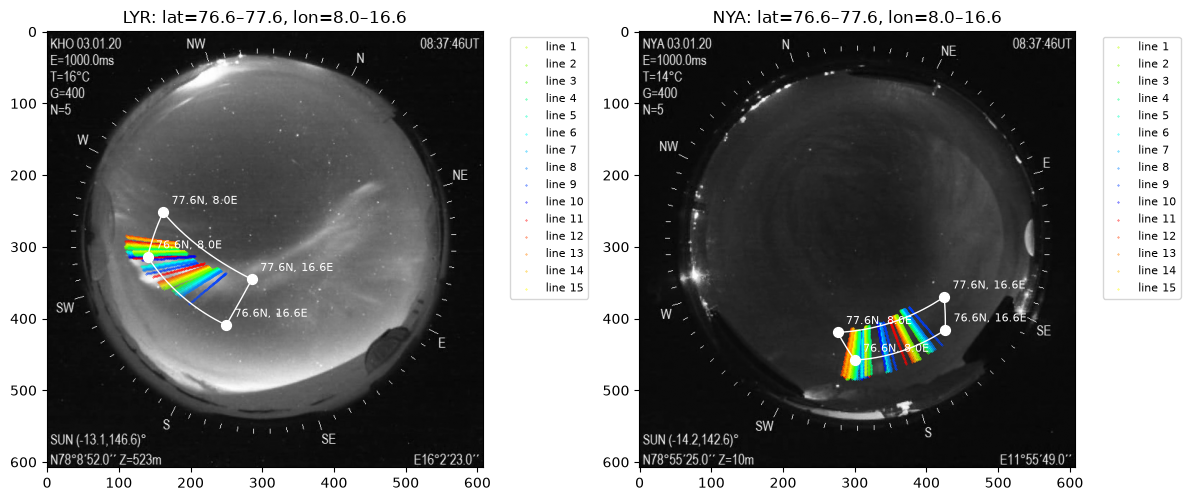

lat=76.6–77.6, lon=8.0–16.6 LYR:152.0, NYA:146.0
LYR  141.0 ± 25.6 km (std),  SEM 3.5 km
NYA  133.6 ± 31.0 km (std),  SEM 4.2 km
Both 137.3 ± 28.6 km (std),  SEM 2.7 km
Saved: out/greyscale_out_fiedline_WISC_20200103083746/20200103083746_profiles_single.png


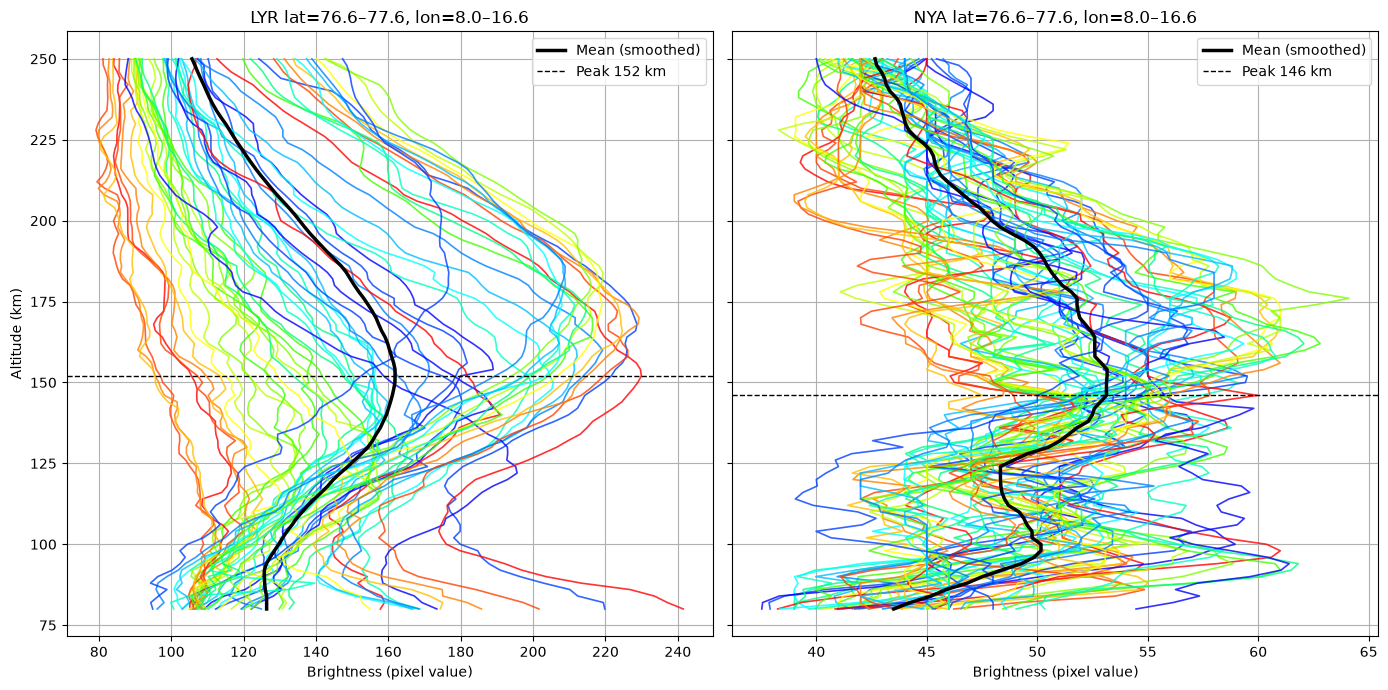

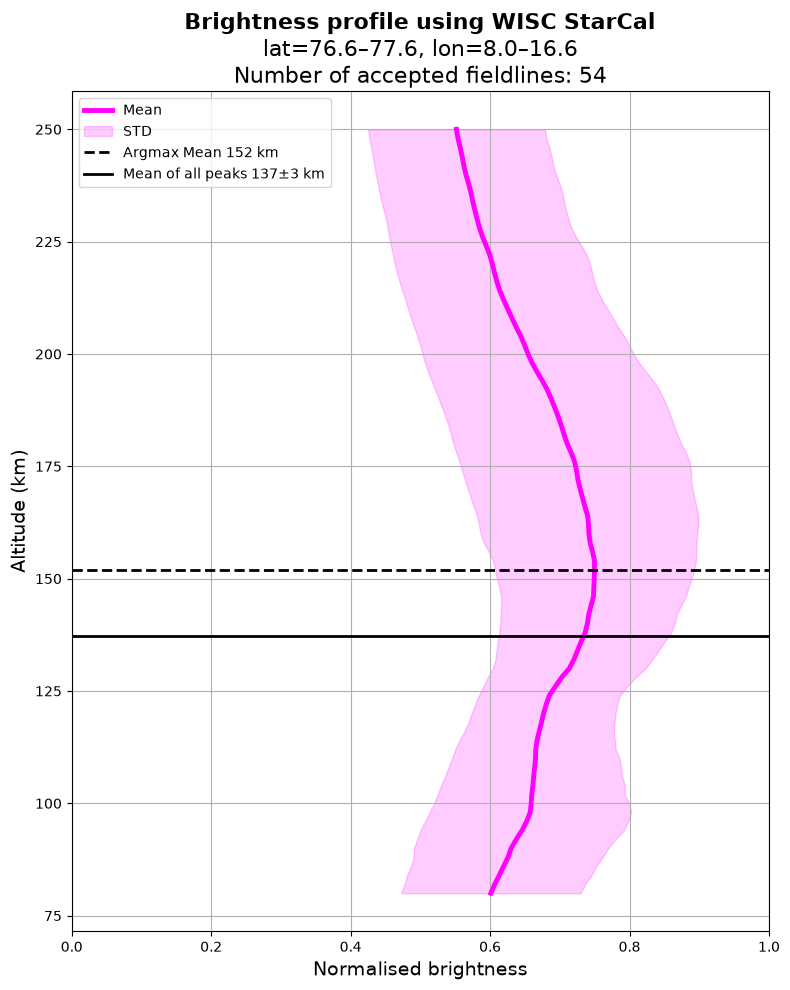

In [9]:
make_plots(selected_brightness_LYR, selected_brightness_NYA, alt_fieldline_last, selected_lines_LYR, selected_lines_NYA, lat_range, lon_range, save_prefix=date_time)